In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
%matplotlib inline

# Bank Customer Segmentation Analysis - Student Exercise

In this lab, you will implement customer segmentation using K-means clustering. You'll learn how to:
1. Preprocess data for clustering
2. Perform and visualize dimensionality reduction
3. Implement K-means clustering from scratch
4. Evaluate clustering results

Follow the instructions in each section and fill in the code where indicated.

In [2]:
# Load Data and Preprocess
def load_data(filepath):
    pass

#================ FOR PCA Dimensionality reduction =========
# Apply PCA for Dimensionality Reduction
def apply_pca(x, n_components):
    pass

#================ FOR K-Means ===============================
# Find Optimal Clusters for KMeans (Elbow Method) 
def find_optimal_clusters(x, max_clusters=10):
    pass

# Perform KMeans Clustering 
# Change None to the number of n_clusters value from the elbow method
def perform_kmeans_clustering(x, n_clusters=None):
    pass

#================ FOR Agglomerative ===============================
# Perform Agglomerative Clustering 
# Change None to the number of n_clusters value from the elbow method
def perform_agglomerative_clustering(x, n_clusters=None):
    pass

#================FOR Dendrogram===============================
# Get Linkages for Dendrogram
def get_linkages(x):
    pass

# Plot Dendrogram
def plot_dendrogram(linked):
    pass

## 1. Data Loading and Preprocessing

First, complete the data preprocessing function below. You need to:
1. Load the data
2. Handle categorical variables
3. Scale numerical features

Data shape: (45211, 9)


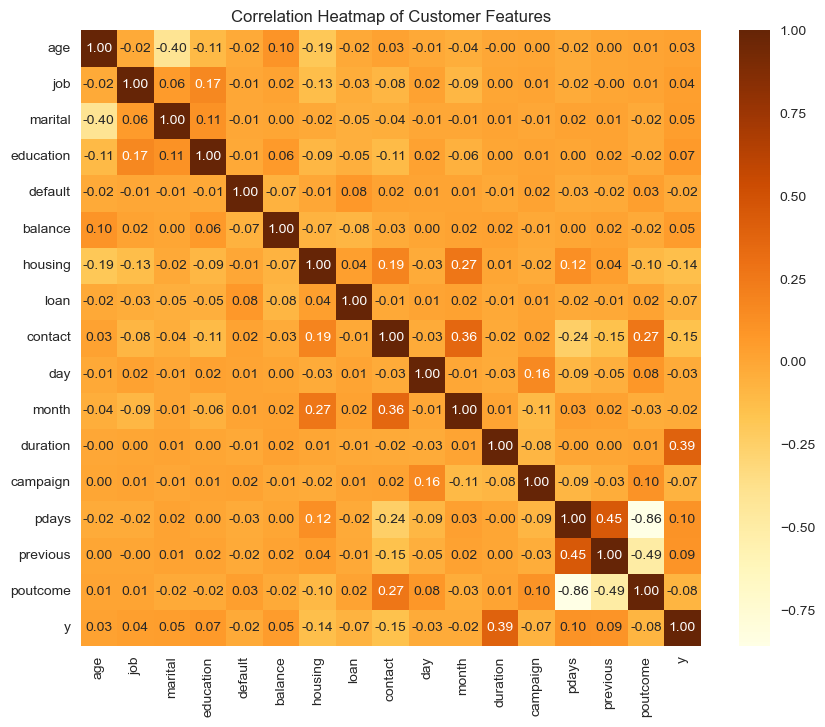

In [3]:
def load_data(filepath):
    """Load and preprocess the bank marketing dataset.
    
    TODO:
    1. Load the CSV file (hint: it uses semicolon separator)
    2. Convert categorical columns to numerical using LabelEncoder
    3. Scale the features using StandardScaler
    """
    # Your code here:
    # Load data
    df = pd.read_csv(filepath, sep=';') # TODO: Load CSV with correct separator
    
    # List of categorical columns to encode
    categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 
                       'loan', 'contact', 'month', 'poutcome', 'y']
    
    # TODO: Apply label encoding to categorical columns
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])
    
    # Select features for clustering
    features = ['age', 'balance', 'campaign', 'previous', 'job', 'education', 
               'housing', 'loan', 'default']
    X = df[features] # TODO: Select features
    
    # TODO: Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X) # TODO: Apply StandardScaler
    
    return X_scaled, df

# Load and preprocess the data
X_scaled, data = load_data('bank-full.csv')
print("Data shape:", X_scaled.shape)

plt.figure(figsize=(10, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='YlOrBr', fmt=".2f")
plt.title("Correlation Heatmap of Customer Features")
plt.show()

In [4]:
class KMeansClustering:
    """Minimal K-means skeleton for students to implement.

    Students should implement the core methods below:
    - _initialize_centroids
    - _assign_clusters
    - _update_centroids
    - fit

    Keep implementations simple and readable; tests and visualization code will
    use these methods once implemented.
    """
    def __init__(self, n_clusters=3, max_iters=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels = None

    def _initialize_centroids(self, X):
        """Initialize centroids.

        TODO (student):
        - Randomly select `n_clusters` distinct points from X as initial centroids.
        - Return an array of shape (n_clusters, n_features).
        Hint: Use np.random.choice to pick indices.
        """
        np.random.seed(self.random_state)
        idx = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        return X[idx]
        
        raise NotImplementedError("_initialize_centroids must be implemented by the student")

    def _assign_clusters(self, X):
        """Assign each sample in X to the nearest centroid.

        TODO (student):
        - Compute distance from each point to each centroid (Euclidean)
        - Return an integer array of shape (n_samples,) with cluster labels
        Hint: np.linalg.norm with axis manipulation or broadcasting helps here.
        """
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)
        
        raise NotImplementedError("_assign_clusters must be implemented by the student")

    def _update_centroids(self, X, labels):
        """Recompute centroids as the mean of points assigned to each cluster.

        TODO (student):
        - For each cluster id in 0..n_clusters-1 compute the mean of points
          assigned to that cluster. If a cluster has no points, consider reinitializing
          its centroid (or leave unchanged) — discuss in your report.
        - Return an array of shape (n_clusters, n_features).
        """
        new_centroids = []

        for k in range(self.n_clusters):
            cluster_points = X[labels == k]

            if len(cluster_points) == 0:
                # No points assigned — reinitialize randomly
                new_centroids.append(X[np.random.randint(0, X.shape[0])])
            else:
                new_centroids.append(cluster_points.mean(axis=0))

        return np.vstack(new_centroids)
        
        raise NotImplementedError("_update_centroids must be implemented by the student")

    def fit(self, X):
        """Run K-means until convergence or max_iters.

        TODO (student):
        - Initialize centroids
        - Loop: assign clusters, update centroids
        - Stop early if centroids do not change (or change below a tiny threshold)
        - Store final labels in self.labels and centroids in self.centroids
        - Return self
        """
        self.centroids = self._initialize_centroids(X)

        for _ in range(self.max_iters):
            labels = self._assign_clusters(X)
            new_centroids = self._update_centroids(X, labels)
            if np.allclose(self.centroids, new_centroids, atol=1e-4):
                break

            self.centroids = new_centroids

        self.labels = labels
        return self
        
        raise NotImplementedError("fit must be implemented by the student")

    def predict(self, X):
        """Assign cluster labels to X using the learned centroids.

        Implementation may call _assign_clusters but should error if centroids
        are not yet initialized (i.e., if fit wasn't called).
        """
        if self.centroids is None:
            raise ValueError("Model has not been fitted yet. Call fit(X) first.")
        return self._assign_clusters(X)


## 2. Dimensionality Reduction

Before clustering, we often reduce the dimensionality of our data for better visualization and performance. Implement PCA below:

In [5]:
def apply_pca(X, n_components=2):
    """Apply PCA for dimensionality reduction.
    
    TODO:
    1. Initialize and fit PCA
    2. Transform the data
    3. Create visualizations to understand:
       - Explained variance ratio
       - Cumulative explained variance
       - Data distribution in 2D
    """
    # Your code here:
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    
    full_pca = PCA().fit(X)
    exp_var = full_pca.explained_variance_ratio_
    cum_exp_var = np.cumsum(exp_var)
    
    # TODO: Create visualization
    plt.figure(figsize=(12, 4))
    
    # Plot explained variance
    plt.subplot(1, 3, 1)
    plt.bar(range(1, len(exp_var) + 1), exp_var)
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Explained Variance per Component")

    plt.subplot(1, 3, 2)
    plt.plot(range(1, len(cum_exp_var) + 1), cum_exp_var, marker='o')
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("Cumulative Explained Variance")
    
    # Plot data in 2D
    plt.subplot(1, 3, 3)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.title("Data distribution in 2D PCA space")
    
    return X_pca

# Apply PCA
X_pca = apply_pca(X_scaled)
print("Shape after PCA:", X_pca.shape)

Shape after PCA: (45211, 2)


## 3. Clustering Evaluation

Implement functions to evaluate the quality of your clustering results:

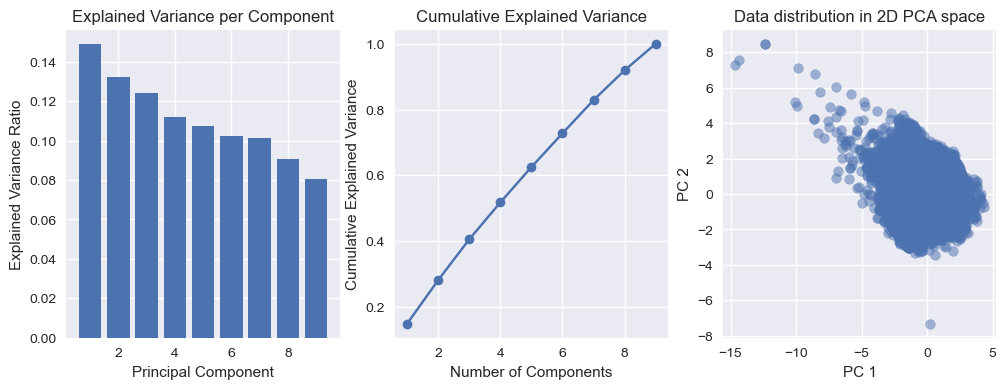

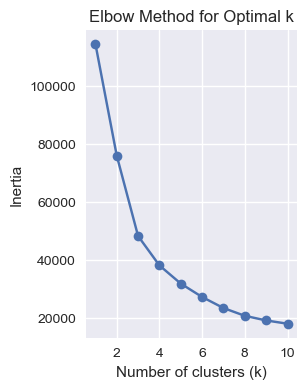

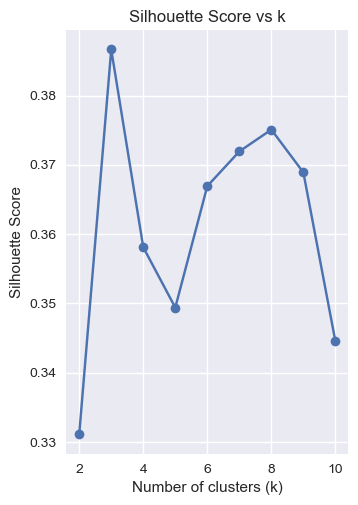

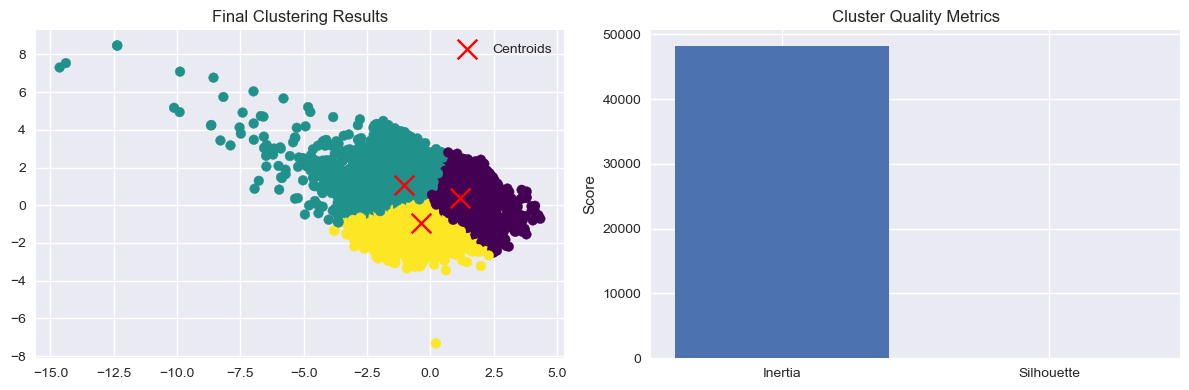


Clustering Evaluation:
Inertia: 48179.64
Silhouette Score: 0.39


In [6]:
def calculate_inertia(X, labels, centroids):
    """Calculate the within-cluster sum of squares (inertia).
    
    TODO:
    1. For each cluster, calculate the sum of squared distances
       between points and their centroid
    2. Sum up all cluster distances
    """
    # Your code here
    inertia = 0
    # Calculate distances between points and their assigned centroids
    for k in range(centroids.shape[0]):
        cluster_points = X[labels == k]
        inertia += np.sum(np.linalg.norm(cluster_points - centroids[k], axis=1) ** 2)
    return inertia

def plot_elbow_curve(X, max_k=10):
    """Plot the elbow curve to find optimal number of clusters.
    
    TODO:
    1. Try different values of k (1 to max_k)
    2. Calculate inertia for each k
    3. Plot k vs inertia
    4. Help identify the 'elbow' point
    """
    # Your code here
    inertias = []
    sil_scores = []
    K = range(1, max_k + 1)
    
    # Calculate inertia for different k values
    for k in K:
        model = KMeansClustering(n_clusters=k)
        model.fit(X)
        inertia_k = calculate_inertia(X, model.labels, model.centroids)
        inertias.append(inertia_k)
        
        if k == 1:
            sil_scores.append(np.nan)
        else:
            sil_scores.append(silhouette_score(X, model.labels))
    
    # Create elbow plot
    plt.figure(figsize=(6, 4))

    plt.subplot(1, 2, 1)
    plt.plot(K, inertias, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method for Optimal k")
    plt.grid(True)
    plt.show()

    plt.subplot(1, 2, 2)
    plt.plot(K, sil_scores, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.title("Silhouette Score vs k")
    plt.grid(True)
    
    return inertias, sil_scores

# Try different numbers of clusters
inertias, sil_scores = plot_elbow_curve(X_pca)

# Apply final clustering
kmeans = KMeansClustering(n_clusters=3)  # Try different values based on elbow curve
kmeans.fit(X_pca)

# Visualize final results
plt.figure(figsize=(12, 4))

# Plot clusters
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels, cmap='viridis')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], 
            c='red', marker='x', s=200, label='Centroids')
plt.title('Final Clustering Results')
plt.legend()

# Plot evaluation metrics
plt.subplot(1, 2, 2)
plt.bar(['Inertia', 'Silhouette'], [calculate_inertia(X_pca, kmeans.labels, kmeans.centroids), silhouette_score(X_pca, kmeans.labels)])
plt.title("Cluster Quality Metrics")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

# Calculate and print evaluation metrics
inertia = calculate_inertia(X_pca, kmeans.labels, kmeans.centroids)
silhouette = silhouette_score(X_pca, kmeans.labels)

print("\nClustering Evaluation:")
print(f"Inertia: {inertia:.2f}")
print(f"Silhouette Score: {silhouette:.2f}")

C:\Users\Nandita R Nadig\AppData\Local\Temp\ipykernel_10488\3201898265.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(silhouette_data, labels=[f"Cluster {c}" for c in cluster_ids])


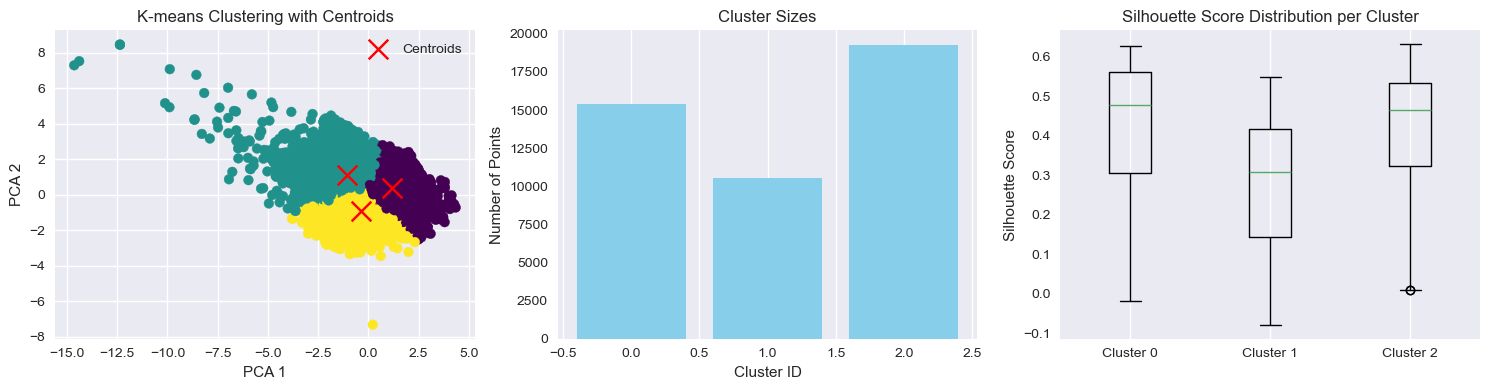

In [7]:
from sklearn.metrics import silhouette_samples
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels, cmap='viridis')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
            c='red', marker='x', s=200, label='Centroids')
plt.title("K-means Clustering with Centroids")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()


cluster_ids, counts = np.unique(kmeans.labels, return_counts=True)

plt.subplot(1, 3, 2)
plt.bar(cluster_ids, counts, color='skyblue')
plt.title("Cluster Sizes")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Points")
plt.grid(axis='y')


sil_values = silhouette_samples(X_pca, kmeans.labels)

silhouette_data = []
for cid in cluster_ids:
    silhouette_data.append(sil_values[kmeans.labels == cid])

plt.subplot(1, 3, 3)
plt.boxplot(silhouette_data, labels=[f"Cluster {c}" for c in cluster_ids])
plt.title("Silhouette Score Distribution per Cluster")
plt.ylabel("Silhouette Score")
plt.grid(axis='y')

plt.tight_layout()
plt.show()

## 4. Recursive Bisecting K-means (Student exercise)

This is an optional exercise for students who want to explore a hierarchical variant of K-means.

Task: implement a concise bisecting K-means procedure that recursively splits clusters into two until a target number of clusters is reached.

Learning goals:
- Understand how repeated binary splits can form a hierarchical clustering
- Practice applying K-means on subclusters and tracking labels/centroids

Hints:
- You can use sklearn's KMeans(k=2) for the binary split step, or reuse your `KMeansClustering` implementation.
- Keep label bookkeeping simple: use increasing integer labels for new clusters.
- Store split metadata (parent -> left/right) to enable a tree visualization later.

In [8]:
class BisectingKMeans:
    """Concise skeleton for students to implement a bisecting K-means algorithm.

    Students should implement `fit_predict` to recursively split clusters until
    `n_clusters` is reached.
    """
    def __init__(self, n_clusters, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.labels_ = None
        # Optional: store mapping parent -> (left_label, right_label)
        self.split_tree = {}
        # Optional: store centroids per cluster id
        self.centers_ = {}

    def fit_predict(self, X):
        """Recursively bisect clusters until `n_clusters` is reached.

        TODO (student):
        - Start with all points assigned to label 0.
        - While number of unique labels < n_clusters:
            - Select a cluster to split (e.g., the largest cluster by size)
            - Run a binary KMeans (k=2) on the points in that cluster
            - Assign new labels (keep one child label as the original, give the other a new id)
            - Record parent -> (left, right) in `self.split_tree` and centroids in `self.centers_`
        - Set and return `self.labels_` (numpy array of length n_samples)

        Hints:
        - Use sklearn.cluster.KMeans(n_clusters=2, random_state=self.random_state) for the split step
        - Keep a counter for new label ids and increment when creating a new cluster
        - Use boolean indexing to operate on subsets of X efficiently
        """
        n_samples = X.shape[0]

        labels = np.zeros(n_samples, dtype=int)
        current_num_clusters = 1
        next_label_id = 1   

        self.centers_[0] = np.mean(X, axis=0)

        while current_num_clusters < self.n_clusters:
            cluster_sizes = {label: np.sum(labels == label) for label in np.unique(labels)}
            cluster_to_split = max(cluster_sizes, key=cluster_sizes.get)

            cluster_points = X[labels == cluster_to_split]

            kmeans2 = KMeans(n_clusters=2, random_state=self.random_state)
            split_labels = kmeans2.fit_predict(cluster_points)
            child_centers = kmeans2.cluster_centers_

            left_label = cluster_to_split
            right_label = next_label_id
            next_label_id += 1

            mask = (labels == cluster_to_split)
            labels[mask] = np.where(split_labels == 0, left_label, right_label)

            self.centers_[left_label] = child_centers[0]
            self.centers_[right_label] = child_centers[1]
            self.split_tree[cluster_to_split] = (left_label, right_label)

            current_num_clusters += 1

        self.labels_ = labels
        return labels
        
        raise NotImplementedError('Implement the bisecting algorithm as a student exercise')

# Example (for instructor use only):
# bisect = BisectingKMeans(n_clusters=4)
# labels = bisect.fit_predict(X_pca)
# plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)


C:\Users\Nandita R Nadig\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Nandita R Nadig\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Nandita R Nadig\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Nandita R Nadig\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Nandita R Nadig\anaconda3\Lib\subprocess.py", line 1538, in _exec

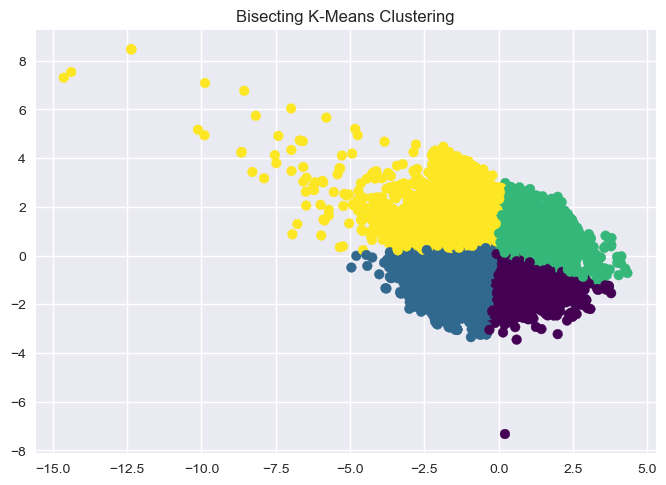

In [9]:
from sklearn.cluster import KMeans
bisect = BisectingKMeans(n_clusters=4)
labels = bisect.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels, cmap = 'viridis')
plt.title("Bisecting K-Means Clustering")
plt.show()

In [10]:
score = silhouette_score(X_pca, labels)
print("Silhouette Score for Bisecting K-Means:", score)

Silhouette Score for Bisecting K-Means: 0.33606596230677205


## Bonus Challenges

If you've completed the main tasks, try these extensions:

1. Implement k-means++ initialization
   - Instead of random initialization, use the k-means++ algorithm
   - This should give better and more consistent results

2. Add cluster interpretation
   - Analyze the characteristics of each cluster
   - What features distinguish one cluster from another?
   - Create visualizations to show cluster properties

3. Try different distance metrics
   - Implement Manhattan distance instead of Euclidean
   - Compare the clustering results

4. Add outlier detection
   - Identify points far from all centroids
   - How might you handle these outliers?

Remember to document your code and explain your findings!

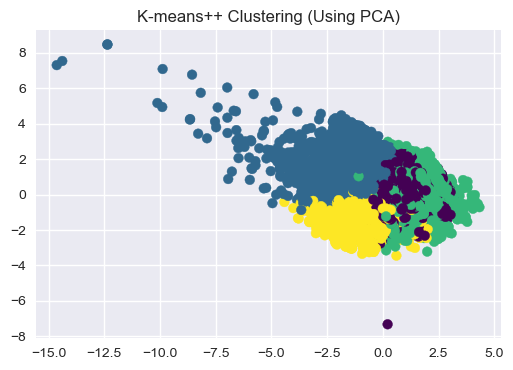

Cluster Centers (original scaled space):
[[-2.40823859e-01 -1.20479523e-01 -5.66572085e-02  4.01968158e-02
  -7.89940948e-01 -1.68356672e-01  6.89018606e-01 -4.36803470e-01
  -1.06208936e-02]
 [ 1.14686977e+00  4.76444130e-01  5.69286028e-03 -4.47820622e-02
  -9.93129151e-02 -8.90210128e-02 -9.40572680e-01 -4.33846998e-01
  -7.43567582e-02]
 [-3.71090865e-02 -2.04218392e-01  2.33983550e-02 -2.55093092e-02
  -7.58989205e-02 -1.12603797e-01  9.57236413e-02  2.28935910e+00
   1.77248634e-01]
 [-4.87519815e-01 -8.04639339e-02  4.60183913e-02 -5.40702224e-04
   9.74018717e-01  3.04119479e-01 -1.74189971e-01 -4.36803470e-01
  -3.18609382e-02]]


In [11]:
kmeans_plus = KMeans(n_clusters=4, init='k-means++', random_state=42)
labels_plus = kmeans_plus.fit_predict(X_scaled)

plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_plus, cmap='viridis')
plt.title("K-means++ Clustering (Using PCA)")
plt.show()

print("Cluster Centers (original scaled space):")
print(kmeans_plus.cluster_centers_)

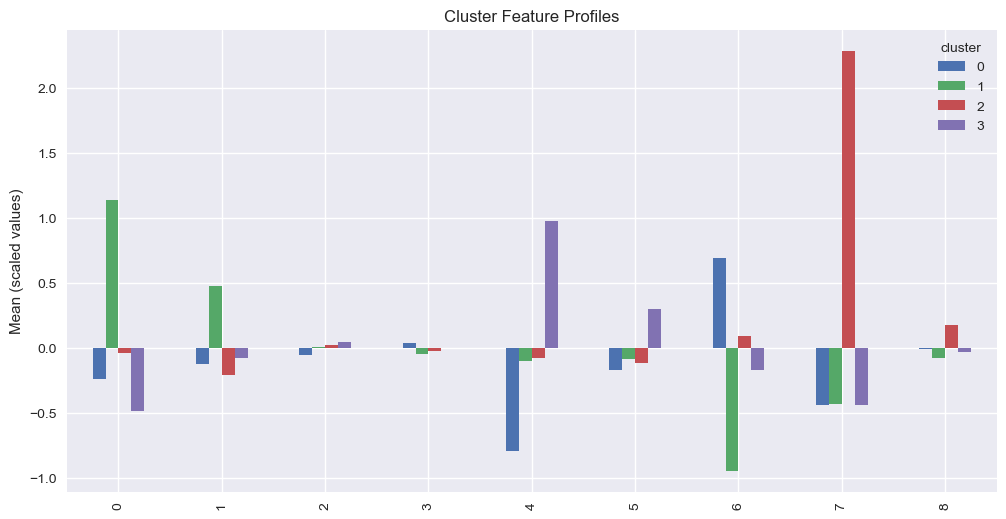

In [12]:
df_clusters = pd.DataFrame(X_scaled) 
df_clusters['cluster'] = labels_plus

cluster_summary = df_clusters.groupby('cluster').mean()

cluster_summary.T.plot(kind='bar', figsize=(12,6))
plt.title("Cluster Feature Profiles")
plt.ylabel("Mean (scaled values)")
plt.show()

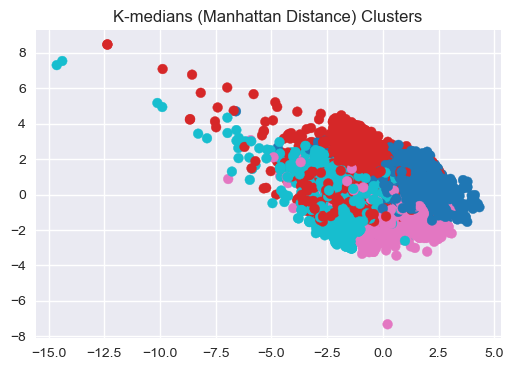

In [13]:
def manhattan_distance(a, b):
    return np.sum(np.abs(a - b), axis=1)

def kmedians(X, k, max_iter=100):
    np.random.seed(42)
    centroids = X[np.random.choice(len(X), k, replace=False)]
    
    for _ in range(max_iter):
        labels = np.array([np.argmin([manhattan_distance([x], c) for c in centroids]) for x in X])
        new_centroids = np.array([np.median(X[labels == i], axis=0) for i in range(k)])
        
        if np.allclose(centroids, new_centroids):
            break
        
        centroids = new_centroids
        
    return labels, centroids

labels_manhattan, centroids_manhattan = kmedians(X_scaled, k=4)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_manhattan, cmap='tab10')
plt.title("K-medians (Manhattan Distance) Clusters")
plt.show()

Number of outliers detected: 1357


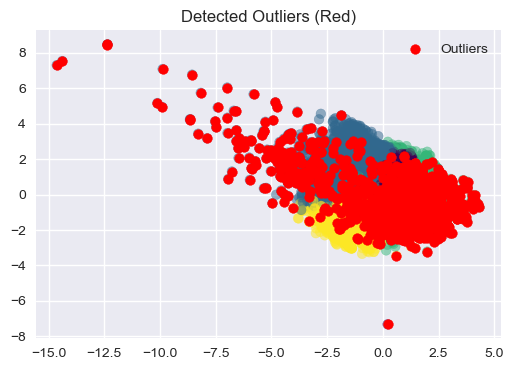

In [14]:
from sklearn.metrics import pairwise_distances

distances = pairwise_distances(X_scaled, kmeans_plus.cluster_centers_)
min_distances = distances.min(axis=1)

threshold = np.percentile(min_distances, 97)  
outliers = np.where(min_distances > threshold)[0]

print(f"Number of outliers detected: {len(outliers)}")

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_plus, cmap='viridis', alpha=0.5)
plt.scatter(X_pca[outliers,0], X_pca[outliers,1], color='red', label='Outliers')
plt.title("Detected Outliers (Red)")
plt.legend()
plt.show()